# Notebook 01: Data Collection - Clinical Trial Failure Prediction for Cancer

## 1. Overview

Notebook này thực hiện việc **thu thập dữ liệu** cho bài toán *dự đoán nguy cơ thất bại của thử nghiệm lâm sàng ung thư* từ **ClinicalTrials.gov API**. Dữ liệu được tải về và lưu trữ dưới dạng **JSONL**, sau đó được **làm phẳng (flatten) và chuyển đổi sang dạng CSV** để phục vụ cho các bước phân tích và tiền xử lý trong các notebook tiếp theo.

### 1.1. Lý do thu thập dữ liệu JSON thô

Dữ liệu từ ClinicalTrials.gov API được cung cấp dưới dạng **các đối tượng JSON có cấu trúc lồng nhau nhiều tầng**, bao gồm thông tin về thiết kế nghiên cứu, trạng thái, đối tượng tham gia, can thiệp và kết quả.

Việc thu thập và lưu trữ dữ liệu ở dạng **JSON thô** giúp:
- **Bảo toàn toàn bộ cấu trúc và thông tin gốc** của mỗi thử nghiệm lâm sàng trước khi làm phẳng.
- **Tránh mất mát dữ liệu** trong quá trình chuyển đổi sang dạng bảng.
- Cho phép **kiểm tra chất lượng, truy vết lỗi và tái lập quá trình thu thập dữ liệu** khi cần thiết.

### 1.2. Output và file hệ thống
- Hàm `collect_raw_jsonl(cfg)` thực hiện thu thập dữ liệu và ghi ra:
    - **Raw JSONL**: `data/raw/ctgov_raw.jsonl`
    - **Log**: `data/raw/logs/ctgov_collect.log`
    - **Metadata**: `data/raw/ctgov_metadata.json`

- Hàm `flatten_raw_jsonl_to_csv(raw_path)` đọc file JSONL và xuất dữ liệu đã được làm phẳng:
    - **CSV đã làm phẳng**: `data/processed/ctgov_flat.csv`

### 1.3. Quy trình thu thập dữ liệu

1. Gọi `api_smoke_test(cfg)` để kiểm tra kết nối API, tham số truy vấn và xác nhận có dữ liệu.

2. Gọi `collect_raw_jsonl(cfg)` để tải toàn bộ hồ sơ theo `cfg.query_term` (vd: "cancer") và trả về `(raw_path, log_path)`.

3. Gọi `flatten_raw_jsonl_to_csv(raw_path)` để chuyển đổi dữ liệu từ JSONL $\rightarrow$ CSV nhằm phục vụ cho các bước phân tích và tiền xử lý.


## 2. Environment Setup and Configuration

### 2.1 Imports and Project Setup
Thư mục gốc của dự án được thêm vào `sys.path` để đảm bảo notebook có thể truy cập và import các module nội bộ trong thư mục `src/`.

In [1]:
import sys 
import json
import importlib 
import numpy as np
import pandas as pd
from pathlib import Path 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
masked_root = str(project_root).replace(str(Path.home()), "~")
masked_root

'~/Clinical-Trial-Failure-Prediction'

### Reload module custom (XÓA)
Các module nội bộ được reload để đảm bảo notebook sử dụng phiên bản code mới nhất trong quá trình phát triển và chỉnh sửa.

In [2]:
for mod in ['src.utils.config', 'src.data.data_loader']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

print('Reload done')

Reload done


### 2.2. Configuration
Cấu hình thu thập dữ liệu được sử dụng để truy vấn các thử nghiệm lâm sàng liên quan đến ung thư từ ClinicalTrials.gov API. Chỉ các nghiên cứu can thiệp (Interventional) và các thử nghiệm đã có trạng thái kết thúc được lựa chọn nhằm phục vụ bài toán học có giám sát.

Các tham số như số lượng bản ghi tối đa, kích thước trang và cơ chế retry được cấu hình để đảm bảo quá trình thu thập dữ liệu ổn định và phù hợp với giới hạn của API.

In [3]:
from src.utils.config import CollectConfig
from src.data.data_loader import (
    api_smoke_test,
    collect_raw_jsonl,
    flatten_raw_jsonl_to_csv,
    raw_quality_report,
)

cfg = CollectConfig(
    query_term='(cancer OR neoplasm OR carcinoma OR tumor OR malignan*)',
    study_type_filter="INTERVENTIONAL",
    phase_filter=["PHASE2", "PHASE3"], 
    overall_status_filter=["COMPLETED", "TERMINATED", "WITHDRAWN"],
    max_studies=30000,
    page_size=1000,
    sleep_s=0.3,
    timeout_s=30,
    max_retries=5,
    retry_delay_s=2.0,
    max_retry_delay_s=30.0,
    retry_jitter_s=0.2,
    prediction_time="t0 = StartDate",
    label_definition="Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}",
)

### 2.3. Configuration Summary

In [4]:
cfg.print_config_summary()

DATA COLLECTION CONFIGURATION

QUERY PARAMETERS:
  Query Term:     (cancer OR neoplasm OR carcinoma OR tumor OR malignan*)
  Study Type:     INTERVENTIONAL
  Phases:         PHASE2, PHASE3
  Status Filter:  COMPLETED, TERMINATED, WITHDRAWN

COLLECTION LIMITS:
  Max Studies:    30,000
  Page Size:      1,000

API SETTINGS:
  Sleep Time:     0.3s
  Timeout:        30s
  Max Retries:    5
  Retry Delay:    2.0s - 30.0s
  Retry Jitter:   ±0.2s

PREDICTION TASK:
  Timepoint:      t0 = StartDate
  Label:          Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}


Kết quả trên cho thấy các tham số truy vấn, giới hạn thu thập dữ liệu và định nghĩa nhãn đã được thiết lập đúng theo mục tiêu bài toán.  
Cấu hình này được sử dụng cho các bước thu thập dữ liệu tiếp theo.

## 3. Data Collection Pipeline

### 3.1. API Connectivity Test (Smoke Test)

In [5]:
ok, info = api_smoke_test(cfg)
ok, info

[2025-12-13 09:27:12,960] INFO - Running API smoke test...
[2025-12-13 09:27:13,567] INFO - Smoke test passed: 5 studies found


(True,
 {'status_code': 200,
  'endpoint': 'https://clinicaltrials.gov/api/v2/studies',
  'params': {'query.term': '((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND (AREA[OverallStatus]COMPLETED OR AREA[OverallStatus]TERMINATED OR AREA[OverallStatus]WITHDRAWN)',
   'pageSize': 5},
  'has_studies_key': True,
  'studies_len': 5,
  'has_nextPageToken': True,
  'top_keys': ['studies', 'nextPageToken']})

Kết quả smoke test cho thấy kết nối tới ClinicalTrials.gov API hoạt động bình thường và truy vấn trả về dữ liệu hợp lệ. Do đó, quá trình thu thập dữ liệu đầy đủ có thể được thực hiện.

### 3.2. Full Data Collection Process
Quá trình thu thập dữ liệu bao gồm các bước chính sau:
- Gọi ClinicalTrials.gov API với các bộ lọc đã cấu hình
- Phân trang kết quả theo kích thước trang xác định
- Lưu toàn bộ dữ liệu thô dưới dạng JSONL
- Ghi log và metadata cho mục đích truy vết và tái lập
- Tính checksum (SHA256) để kiểm tra tính toàn vẹn dữ liệu

Các tệp đầu ra được tạo trong quá trình thu thập bao gồm:
- **Raw JSONL**: `data/raw/ctgov_raw.jsonl` - dữ liệu thử nghiệm lâm sàng thô
- **Metadata**: `data/raw/ctgov_metadata.json` - metadata của lần thu thập
- **Log**: `data/raw/logs/ctgov_collect.log` - log ghi nhận quá trình thực thi

In [6]:
raw_path, log_path = collect_raw_jsonl(cfg)

[2025-12-13 09:27:13,574] INFO - Starting data collection from ClinicalTrials.gov API
[2025-12-13 09:27:13,631] INFO - Output files:
[2025-12-13 09:27:13,633] INFO -   Raw JSONL: ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
[2025-12-13 09:27:13,633] INFO -   Log: ~/Clinical-Trial-Failure-Prediction/data/raw/logs/ctgov_collect.log
[2025-12-13 09:27:13,634] INFO -   Metadata: ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_metadata.json


[2025-12-13 09:27:13,666] INFO - Starting API collection with query: ((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (ARE...
[2025-12-13 09:28:45,021] INFO - Collection complete: 30000 studies collected
[2025-12-13 09:28:45,022] INFO -   SHA256: 541e3525dacab03f...


### 3.3. Raw Data Quality Report

Sau khi thu thập dữ liệu, một báo cáo chất lượng được tạo ra nhằm đánh giá:
- Tỷ lệ lỗi parse JSON
- Mức độ đầy đủ của các trường quan trọng
- Sự ổn định của cấu trúc dữ liệu đầu vào 

In [7]:
meta_path = raw_path.parent / "ctgov_metadata.json"

print("Raw JSONL:", str(raw_path).replace(str(Path.home()), "~"))
print("Metadata:", str(meta_path).replace(str(Path.home()), "~") if meta_path.exists() else None)

if meta_path and meta_path.exists():
    meta = json.loads(meta_path.read_text(encoding="utf-8"))
    for k in ["run_started_at","run_finished_at","endpoint","params","total_raw_records","raw_sha256","git_commit",
              "prediction_time","label_definition"]:
        print(f"{k}: {meta.get(k)}")

qa = raw_quality_report(raw_path, max_lines=100000)  
qa

[2025-12-13 09:28:45,040] INFO - Generating quality report for ctgov_raw.jsonl...


Raw JSONL: ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
Metadata: ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_metadata.json
run_started_at: 2025-12-13T09:27:13Z
run_finished_at: 2025-12-13T09:28:44Z
endpoint: https://clinicaltrials.gov/api/v2/studies
params: {'query.term': '((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND (AREA[OverallStatus]COMPLETED OR AREA[OverallStatus]TERMINATED OR AREA[OverallStatus]WITHDRAWN)', 'pageSize': 1000}
total_raw_records: 30000
raw_sha256: 541e3525dacab03f1ea05f68a7947bab8fcb0454a8ac858b8501b9ee6421405b
git_commit: cf4aed2db75bbcf41fac23b7b9213f07e6b4a193
prediction_time: t0 = StartDate
label_definition: Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}


[2025-12-13 09:28:54,478] INFO - Quality Report Summary:
[2025-12-13 09:28:54,478] INFO -   Lines analyzed: 30000
[2025-12-13 09:28:54,479] INFO -   Parse errors: 0 (0.00%)
[2025-12-13 09:28:54,480] INFO -   Complete nct_id: 0.0% missing
[2025-12-13 09:28:54,480] INFO -   Complete overall_status: 0.0% missing
[2025-12-13 09:28:54,481] INFO -   Complete start_date: 1.0% missing
[2025-12-13 09:28:54,481] INFO -   Complete study_type: 0.0% missing


{'raw_path': '~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl',
 'total_lines_read': 30000,
 'json_parse_errors': 0,
 'parse_error_rate': 0.0,
 'missing_critical_counts': {'nct_id': 0,
  'overall_status': 0,
  'start_date': 306,
  'study_type': 0},
 'missing_critical_rates': {'nct_id': 0.0,
  'overall_status': 0.0,
  'start_date': 0.0102,
  'study_type': 0.0},
 'top_level_keys_coverage': {'protocolSection': 30000,
  'derivedSection': 30000,
  'hasResults': 30000,
  'resultsSection': 13347,
  'documentSection': 6386,
  'annotationSection': 380}}

Dữ liệu thu thập có **chất lượng tốt**, với **30,000** bản ghi được đọc thành công và **không phát sinh lỗi parse JSON**.  
Các trường quan trọng như `nct_id`, `overall_status` và `study_type` đều **đầy đủ 100%**, trong khi `start_date` chỉ thiếu **1%**, mức chấp nhận được.  

Nhìn chung, dữ liệu sẵn sàng cho các bước **làm phẳng và tiền xử lý** tiếp theo.

### 3.4. Collection Logs Review
Log của quá trình thu thập dữ liệu được kiểm tra nhằm xác nhận tiến trình thực thi và phát hiện các vấn đề (nếu có) trong quá trình tải dữ liệu. 

In [8]:
print(log_path.read_text(encoding="utf-8"))

{"event": "run_start", "run_started_at": "2025-12-13T09:27:13Z", "run_tag": "20251213_092713", "endpoint": "https://clinicaltrials.gov/api/v2/studies", "params": {"query.term": "((cancer OR neoplasm OR carcinoma OR tumor OR malignan*)) AND AREA[StudyType]INTERVENTIONAL AND (AREA[Phase]PHASE2 OR AREA[Phase]PHASE3) AND (AREA[OverallStatus]COMPLETED OR AREA[OverallStatus]TERMINATED OR AREA[OverallStatus]WITHDRAWN)", "pageSize": 1000}, "timeout_s": 30, "max_retries": 5, "retry_delay_s": 2.0, "sleep_s": 0.3, "max_studies": 30000, "git_commit": "cf4aed2db75bbcf41fac23b7b9213f07e6b4a193", "prediction_time": "t0 = StartDate", "label_definition": "Hard label: Fail={WITHDRAWN,TERMINATED}; Success={COMPLETED}", "raw_path": "/home/thucquyen/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl", "log_path": "/home/thucquyen/Clinical-Trial-Failure-Prediction/data/raw/logs/ctgov_collect.log"}
{"event": "run_finish", "run_finished_at": "2025-12-13T09:28:44Z", "total_raw_records": 30000, "json_wr

Nội dung log cho thấy quá trình thu thập dữ liệu được thực hiện đầy đủ từ khi bắt đầu đến khi kết thúc, không ghi nhận lỗi nghiêm trọng trong quá trình gọi API và ghi dữ liệu.

## 4. Data Flattening and CSV Conversion
### 4.1. Raw JSONL Flattening
Sau khi dữ liệu thô được thu thập và lưu trữ dưới dạng **JSONL**, bước tiếp theo là **làm phẳng (flatten)** cấu trúc JSON nhiều tầng thành dạng **bảng (tabular format)**.  
Dữ liệu sau khi làm phẳng được lưu dưới dạng **CSV**, thuận tiện cho việc phân tích và tiền xử lý trong các notebook tiếp theo.

In [9]:
csv_path = flatten_raw_jsonl_to_csv(raw_path) 

[2025-12-13 09:28:54,502] INFO - Flattening ctgov_raw.jsonl to CSV...
[2025-12-13 09:29:04,447] INFO - Flattening complete: ctgov_flat.csv
[2025-12-13 09:29:04,448] INFO -    Total lines: 30000
[2025-12-13 09:29:04,449] INFO -    Kept records: 30000
[2025-12-13 09:29:04,449] INFO -    Parse errors: 0


Kết quả log cho thấy toàn bộ dữ liệu đã được chuyển đổi thành công, không phát sinh lỗi parse và số lượng bản ghi được giữ nguyên.

### 4.2. Dataset Overview

In [10]:
print("File Path:", str(csv_path).replace(str(Path.home()), "~"))
df = pd.read_csv(csv_path)
print(f"Dimensions: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData Types: \n{df.dtypes.value_counts()}")

File Path: ~/Clinical-Trial-Failure-Prediction/data/processed/ctgov_flat.csv
Dimensions: 30,000 rows × 23 columns
Memory Usage: 38.92 MB

Data Types: 
object     18
int64       3
float64     1
bool        1
Name: count, dtype: int64


### 4.3. Load Processed Dataset

In [11]:
df.head()

,nct_id,brief_title,overall_status,start_date,completion_date,study_type,phases,allocation,intervention_model,primary_purpose,...,lead_sponsor_name,lead_sponsor_class,has_dmc,conditions,num_conditions,intervention_types,intervention_names,num_interventions,num_arms,has_results
0,NCT00005094,Celecoxib to Prevent Colorectal Cancer in Pati...,COMPLETED,2000-03-01,NaN,INTERVENTIONAL,PHASE3,RANDOMIZED,PARALLEL,PREVENTION,...,National Cancer Institute (NCI),NIH,NaN,Colon Cancer|Rectal Cancer,2,DRUG|OTHER,celecoxib|placebo,2,2,False
1,NCT06472531,A Study of PET/CT Imaging Using INR101 Injecti...,COMPLETED,2024-05-23,2024-10-10,INTERVENTIONAL,PHASE1|PHASE2,RANDOMIZED,PARALLEL,DIAGNOSTIC,...,"Yunhe Pharmaceutical (Tianjin) Co., Ltd",OTHER,False,Healthy Male Subjects|Suspected Prostate Cancer,2,DRUG,INR101|INR101,2,2,False
2,NCT00968331,Study of Lenalidomide(Revlimid) Plus Rituximab...,TERMINATED,2009-03-01,2011-12-01,INTERVENTIONAL,PHASE2,NaN,SINGLE_GROUP,TREATMENT,...,University of Bologna,OTHER,NaN,Diffuse Large B-cell Lymphoma,1,DRUG,Lenalidomide plus Rituximab,1,1,False
3,NCT01471353,Sorafenib Plus Capecitabine (SorCape) in Previ...,COMPLETED,2011-11-01,2017-05-01,INTERVENTIONAL,PHASE2,NaN,SINGLE_GROUP,TREATMENT,...,University of Florida,OTHER,True,Colorectal Cancer Metastatic,1,DRUG,Sorafenib Plus Capecitabine (SorCape),1,1,True
4,NCT02268253,Tagraxofusp (SL-401) in Participants With Chro...,COMPLETED,2016-02-10,2023-03-27,INTERVENTIONAL,PHASE1|PHASE2,NON_RANDOMIZED,SEQUENTIAL,TREATMENT,...,"Stemline Therapeutics, Inc.",INDUSTRY,True,Myelofibrosis|Chronic Myelomonocytic Leukemia,2,DRUG,Tagraxofusp Injection,1,6,True


### 4.4. Data Structure and Type Analysis

In [12]:
df.dtypes

nct_id                 object
brief_title            object
overall_status         object
start_date             object
completion_date        object
study_type             object
phases                 object
allocation             object
intervention_model     object
primary_purpose        object
masking                object
enrollment_count      float64
enrollment_type        object
lead_sponsor_name      object
lead_sponsor_class     object
has_dmc                object
conditions             object
num_conditions          int64
intervention_types     object
intervention_names     object
num_interventions       int64
num_arms                int64
has_results              bool
dtype: object

### 4.5. Key Column Definitions
| Tên cột              | Mô tả                                                                  |
| -------------------- | ---------------------------------------------------------------------- |
| `nct_id`             | Mã định danh duy nhất của thử nghiệm lâm sàng trên ClinicalTrials.gov  |
| `brief_title`        | Tiêu đề ngắn mô tả nội dung chính của thử nghiệm                       |
| `overall_status`     | Trạng thái cuối cùng của thử nghiệm (COMPLETED, TERMINATED, WITHDRAWN) |
| `start_date`         | Ngày bắt đầu chính thức của thử nghiệm                                 |
| `completion_date`    | Ngày hoàn tất thử nghiệm (có thể thiếu nếu dừng sớm)                   |
| `study_type`         | Loại nghiên cứu (trong dữ liệu này: INTERVENTIONAL)                    |
| `phases`             | Giai đoạn thử nghiệm lâm sàng (PHASE2, PHASE3, hoặc kết hợp)           |
| `allocation`         | Cách phân bổ đối tượng tham gia (RANDOMIZED / NON_RANDOMIZED)          |
| `intervention_model` | Mô hình can thiệp (PARALLEL, SINGLE_GROUP, SEQUENTIAL, …)              |
| `primary_purpose`    | Mục tiêu chính của thử nghiệm (TREATMENT, PREVENTION, DIAGNOSTIC, …)   |
| `masking`            | Mức độ làm mù (Open-label, Single-blind, Double-blind, …)              |
| `enrollment_count`   | Số lượng người tham gia thử nghiệm                                     |
| `enrollment_type`    | Loại số liệu tuyển chọn (ACTUAL hoặc ESTIMATED)                        |
| `lead_sponsor_name`  | Tên tổ chức/tổ chức chính tài trợ thử nghiệm                           |
| `lead_sponsor_class` | Nhóm nhà tài trợ (INDUSTRY, NIH, OTHER, …)                             |
| `has_dmc`            | Có hay không Ủy ban giám sát dữ liệu (Data Monitoring Committee)       |
| `conditions`         | Danh sách các bệnh/điều kiện được nghiên cứu                           |
| `num_conditions`     | Số lượng điều kiện/bệnh được liệt kê                                   |
| `intervention_types` | Loại can thiệp (DRUG, BIOLOGICAL, DEVICE, …)                           |
| `intervention_names` | Tên các biện pháp/can thiệp được sử dụng                               |
| `num_interventions`  | Số lượng can thiệp trong thử nghiệm                                    |
| `num_arms`           | Số nhánh (arms) của thử nghiệm                                         |
| `has_results`        | Cho biết thử nghiệm đã công bố kết quả hay chưa                        |


## 5. Validation & Quality Check

### 5.1. Missing Data Analysis
Phân tích tỷ lệ giá trị thiếu (missing values) nhằm xác định các biến cần được xử lý trong bước tiền xử lý dữ liệu.

In [13]:
df.isna().mean().sort_values(ascending=False)

allocation            0.420233
has_dmc               0.220233
intervention_model    0.063533
enrollment_type       0.062233
completion_date       0.054367
masking               0.045433
enrollment_count      0.031200
start_date            0.010200
primary_purpose       0.004733
num_arms              0.000000
num_interventions     0.000000
intervention_names    0.000000
intervention_types    0.000000
num_conditions        0.000000
conditions            0.000000
nct_id                0.000000
lead_sponsor_class    0.000000
lead_sponsor_name     0.000000
brief_title           0.000000
phases                0.000000
study_type            0.000000
overall_status        0.000000
has_results           0.000000
dtype: float64

**Nhận xét:**  
Các biến liên quan đến thiết kế thử nghiệm (`allocation`, `has_dmc`) có tỷ lệ thiếu tương đối cao. Các biến này sẽ được xem xét xử lý ở bước tiền xử lý thông qua các chiến lược như: **Giữ nguyên và mã hóa giá trị thiếu (missing as category)** hoặc **loại bỏ** nếu chúng không đóng góp đáng kể cho mô hình.

### 5.2. Duplicate NCT ID Check

In [14]:
duplicate_ids = df['nct_id'].duplicated().sum()
unique_ids = df['nct_id'].nunique()
total_records = len(df)

print("="*60)
print("DUPLICATE CHECK")
print("="*60)
print(f"Total records: {total_records:,}")
print(f"Unique NCT IDs: {unique_ids:,}")
print(f"Duplicate records: {duplicate_ids}")
print(f"Data Uniqueness: {(unique_ids/total_records)*100:.2f}%")

DUPLICATE CHECK
Total records: 30,000
Unique NCT IDs: 30,000
Duplicate records: 0
Data Uniqueness: 100.00%


Kiểm tra trùng lặp cho thấy **100% NCT ID là duy nhất**, không tồn tại bản ghi trùng.  
Điều này xác nhận rằng mỗi thử nghiệm lâm sàng chỉ xuất hiện một lần trong tập dữ liệu sau khi làm phẳng.

### 5.3. Data Quality Assessment
Chất lượng dữ liệu được đánh giá sơ bộ dựa trên các tiêu chí: **Độ đầy đủ (Completeness)**, **Tính duy nhất (Uniqueness)**, **Tính hợp lệ (Validity)** và **Tính nhất quán (Consistency)**.

In [15]:
# 1. Completeness: Percentage of non-missing values
completeness_score = (1 - df.isna().mean().mean()) * 100

# 2. Uniqueness: Check if primary key is unique
uniqueness_score = (df['nct_id'].nunique() / len(df)) * 100

# 3. Validity: Check for logical inconsistencies
validity_score = 100  # Start with perfect score

# Check for negative enrollment numbers
if 'enrollment_count' in df.columns:
    negative_enrollment = (df['enrollment_count'] < 0).sum()
    if negative_enrollment > 0:
        validity_score -= 10
        
# 4. Consistency: Check date fields are in proper format
consistency_score = 100
date_cols = ['start_date', 'completion_date', 'primary_completion_date', 'study_first_submitted_date']
consistency_issues = []
for col in date_cols:
    if col in df.columns:
        # Check if dates are not in future (beyond current data collection date)
        non_null_dates = df[col].notna().sum()
        if non_null_dates == 0:
            consistency_issues.append(f"{col}: All values missing")

# Overall Quality Score (weighted average)
weights = {
    'completeness': 0.35,
    'uniqueness': 0.25,
    'validity': 0.20,
    'consistency': 0.20
}

overall_score = (
    completeness_score * weights['completeness'] +
    uniqueness_score * weights['uniqueness'] +
    validity_score * weights['validity'] +
    consistency_score * weights['consistency']
)

print("="*60)
print("DATA QUALITY ASSESSMENT")
print("="*60)
print(f"1. Completeness Score:  {completeness_score:.2f}% (weight: {weights['completeness']*100}%)")
print(f"   - Measures the percentage of non-missing values")
print(f"\n2. Uniqueness Score:    {uniqueness_score:.2f}% (weight: {weights['uniqueness']*100}%)")
print(f"   - Ensures each trial has a unique identifier")
print(f"\n3. Validity Score:      {validity_score:.2f}% (weight: {weights['validity']*100}%)")
print(f"   - Checks for logical data inconsistencies")
print(f"\n4. Consistency Score:   {consistency_score:.2f}% (weight: {weights['consistency']*100}%)")
print(f"   - Validates data format and relationships")
print("\n" + "="*60)
print(f"OVERALL QUALITY SCORE:  {overall_score:.2f}%")
print("="*60)

# Quality rating
if overall_score >= 90:
    quality_rating = "EXCELLENT"
elif overall_score >= 80:
    quality_rating = "GOOD"
elif overall_score >= 70:
    quality_rating = "ACCEPTABLE"
elif overall_score >= 60:
    quality_rating = "POOR"
else:
    quality_rating = "CRITICAL"
    
print(f"\nQuality Rating: {quality_rating}")

# Recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
recommendations = []
if completeness_score < 80:
    recommendations.append("• Address high missing value rates before modeling")
if uniqueness_score < 100:
    recommendations.append("• Investigate and remove duplicate records")
if validity_score < 100:
    recommendations.append("• Fix logical inconsistencies in the data")
if consistency_issues:
    recommendations.append("• Review date fields for consistency")
    
if recommendations:
    for rec in recommendations:
        print(rec)
else:
    print("No major issues detected. Data is ready for preprocessing.")

DATA QUALITY ASSESSMENT
1. Completeness Score:  96.03% (weight: 35.0%)
   - Measures the percentage of non-missing values

2. Uniqueness Score:    100.00% (weight: 25.0%)
   - Ensures each trial has a unique identifier

3. Validity Score:      100.00% (weight: 20.0%)
   - Checks for logical data inconsistencies

4. Consistency Score:   100.00% (weight: 20.0%)
   - Validates data format and relationships

OVERALL QUALITY SCORE:  98.61%

Quality Rating: EXCELLENT

RECOMMENDATIONS
No major issues detected. Data is ready for preprocessing.


Các chỉ số chất lượng cho thấy bộ dữ liệu đạt mức **EXCELLENT** với độ đầy đủ cao, không có bản ghi trùng lặp và không phát hiện lỗi logic hoặc định dạng nghiêm trọng.  
Do đó, dữ liệu đủ tin cậy để chuyển sang bước tiền xử lý và xây dựng đặc trưng trong các notebook tiếp theo.

### 5.4. Statistical Summary of Collected Data
Phân tích thống kê mô tả nhằm hiểu rõ hơn về các đặc điểm của bộ dữ liệu thử nghiệm lâm sàng ung thư, bao gồm phân bố trạng thái, pha thử nghiệm, loại nghiên cứu và quy mô tuyển sinh.

In [16]:
if 'overall_status' in df.columns:
    print("="*60)
    print("TRIAL STATUS DISTRIBUTION")
    print("="*60)
    status_counts = df['overall_status'].value_counts()
    status_pct = df['overall_status'].value_counts(normalize=True) * 100
    
    for status, count in status_counts.items():
        pct = status_pct[status]
        bar_len = int(pct / 2)  # Scale for visualization
        bar = "█" * bar_len
        print(f"{status:25s} {count:6,} ({pct:5.1f}%) {bar}")
    
    print(f"\nTotal trials: {len(df):,}")
    
# Distribution of Trial Phase
if 'phases' in df.columns:
    print("\n" + "="*60)
    print("TRIAL PHASE DISTRIBUTION")
    print("="*60)
    phase_counts = df['phases'].value_counts()
    phase_pct = df['phases'].value_counts(normalize=True) * 100
    
    for phase, count in phase_counts.items():
        pct = phase_pct[phase]
        bar_len = int(pct / 2)
        bar = "█" * bar_len
        print(f"{str(phase):25s} {count:6,} ({pct:5.1f}%) {bar}")

# Distribution of Study Type
if 'study_type' in df.columns:
    print("\n" + "="*60)
    print("STUDY TYPE DISTRIBUTION")
    print("="*60)
    study_type_counts = df['study_type'].value_counts()
    
    for st, count in study_type_counts.items():
        pct = (count / len(df)) * 100
        bar_len = int(pct / 2)
        bar = "█" * bar_len
        print(f"{str(st):25s} {count:6,} ({pct:5.1f}%) {bar}")

# Enrollment Statistics
if 'enrollment_count' in df.columns:
    print("\n" + "="*60)
    print("ENROLLMENT STATISTICS")
    print("="*60)
    enrollment_data = df['enrollment_count'].dropna()
    
    if len(enrollment_data) > 0:
        print(f"Total trials with enrollment data: {len(enrollment_data):,}")
        print(f"Mean enrollment: {enrollment_data.mean():,.0f} participants")
        print(f"Median enrollment: {enrollment_data.median():,.0f} participants")
        print(f"Min enrollment: {enrollment_data.min():,.0f} participants")
        print(f"Max enrollment: {enrollment_data.max():,.0f} participants")
        print(f"Std deviation: {enrollment_data.std():,.0f} participants")
        
        # Quartiles
        print(f"\nQuartiles:")
        print(f"  25th percentile: {enrollment_data.quantile(0.25):,.0f}")
        print(f"  50th percentile: {enrollment_data.quantile(0.50):,.0f}")
        print(f"  75th percentile: {enrollment_data.quantile(0.75):,.0f}")
        
        # Check for potential outliers
        Q1 = enrollment_data.quantile(0.25)
        Q3 = enrollment_data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = enrollment_data[(enrollment_data < Q1 - 1.5*IQR) | (enrollment_data > Q3 + 1.5*IQR)]
        print(f"\nPotential outliers (IQR method): {len(outliers):,} trials ({len(outliers)/len(enrollment_data)*100:.1f}%)")

TRIAL STATUS DISTRIBUTION
COMPLETED                 21,898 ( 73.0%) ████████████████████████████████████
TERMINATED                 6,180 ( 20.6%) ██████████
WITHDRAWN                  1,922 (  6.4%) ███

Total trials: 30,000

TRIAL PHASE DISTRIBUTION
PHASE2                    18,176 ( 60.6%) ██████████████████████████████
PHASE3                     6,259 ( 20.9%) ██████████
PHASE1|PHASE2              4,782 ( 15.9%) ███████
PHASE2|PHASE3                783 (  2.6%) █

STUDY TYPE DISTRIBUTION
INTERVENTIONAL            30,000 (100.0%) ██████████████████████████████████████████████████

ENROLLMENT STATISTICS
Total trials with enrollment data: 29,064
Mean enrollment: 202 participants
Median enrollment: 46 participants
Min enrollment: 0 participants
Max enrollment: 477,102 participants
Std deviation: 3,206 participants

Quartiles:
  25th percentile: 19
  50th percentile: 46
  75th percentile: 120

Potential outliers (IQR method): 3,673 trials (12.6%)


## 6. Visualization & Visual Analytics

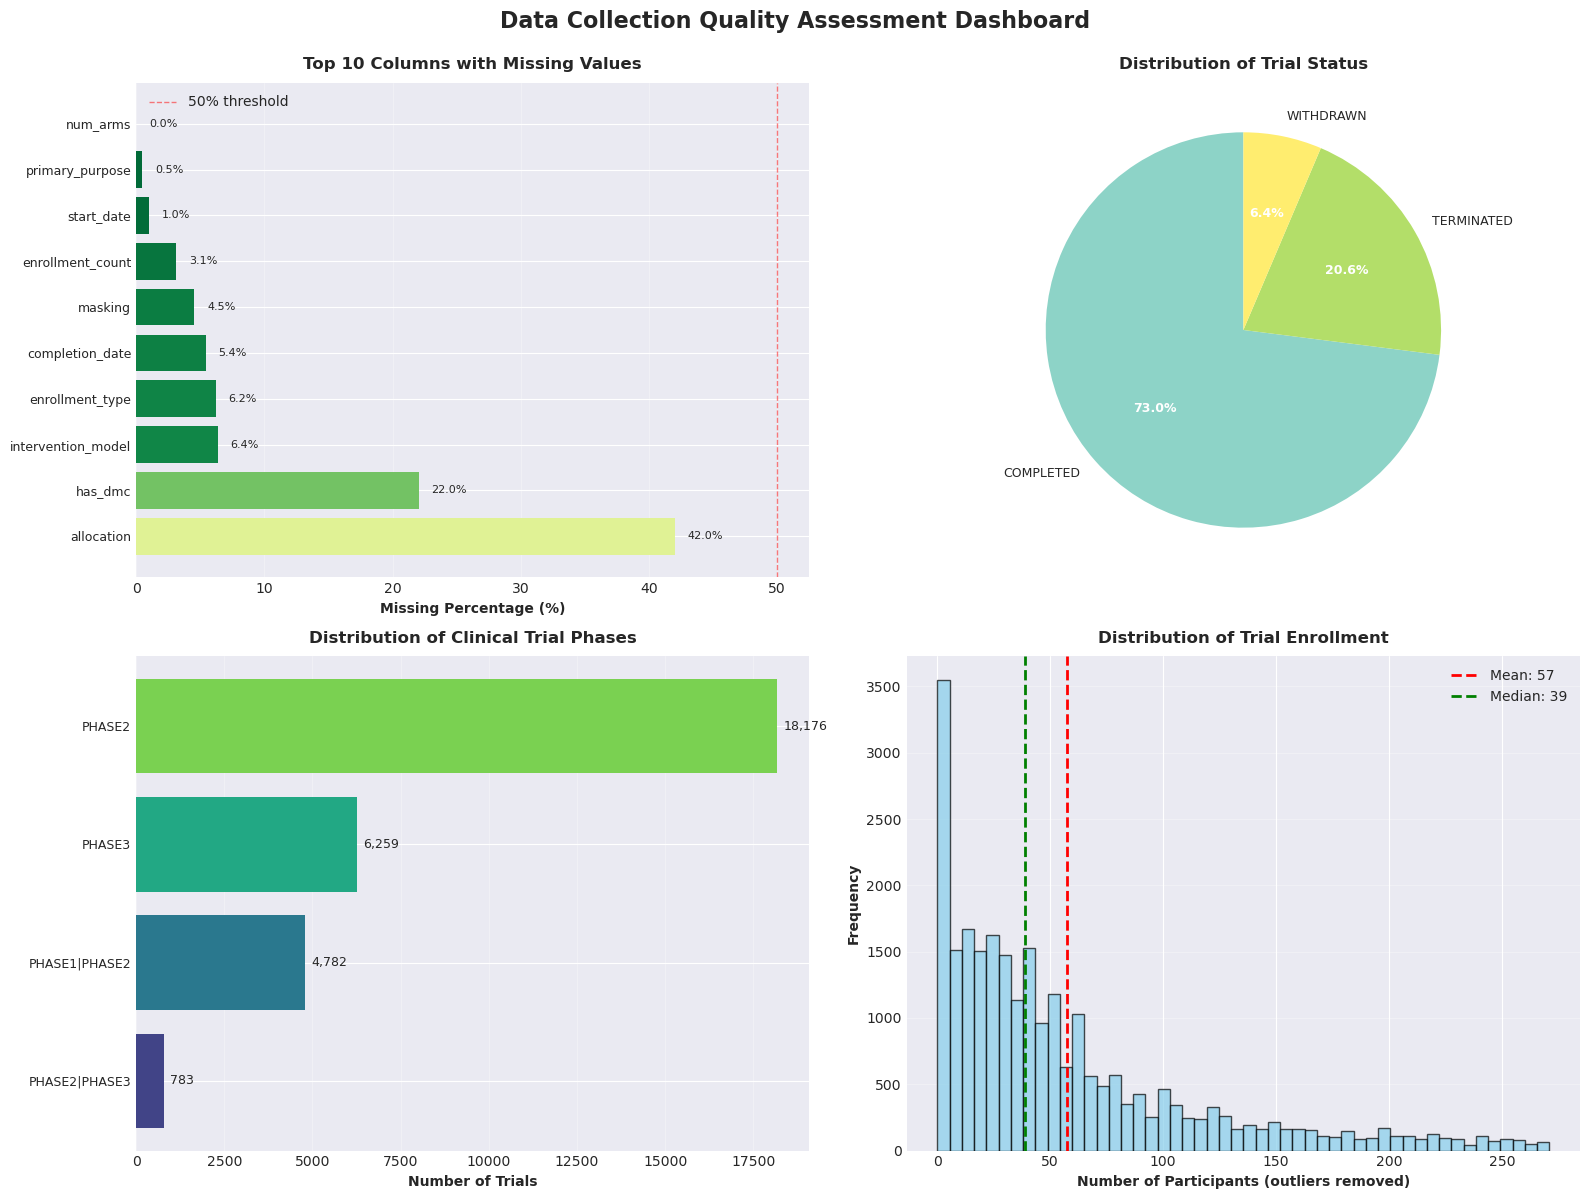

In [17]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

# Create a comprehensive visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Data Collection Quality Assessment Dashboard', fontsize=16, fontweight='bold', y=0.995)

# 1. Top 10 Missing Value Percentages (Top-left)
ax1 = axes[0, 0]
missing_pct = df.isna().mean().sort_values(ascending=False).head(10) * 100
colors = plt.cm.RdYlGn_r(missing_pct / 100)  # Color gradient from green (low) to red (high)

bars = ax1.barh(range(len(missing_pct)), missing_pct, color=colors)
ax1.set_yticks(range(len(missing_pct)))
ax1.set_yticklabels(missing_pct.index, fontsize=9)
ax1.set_xlabel('Missing Percentage (%)', fontweight='bold')
ax1.set_title('Top 10 Columns with Missing Values', fontweight='bold', pad=10)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, missing_pct)):
    ax1.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=8)

# 2. Trial Status Distribution (Top-right)
ax2 = axes[0, 1]
if 'overall_status' in df.columns:
    status_counts = df['overall_status'].value_counts()
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(status_counts)))
    
    wedges, texts, autotexts = ax2.pie(status_counts.values, 
                                         labels=status_counts.index, 
                                         autopct='%1.1f%%',
                                         colors=colors_pie,
                                         startangle=90,
                                         textprops={'fontsize': 9})
    ax2.set_title('Distribution of Trial Status', fontweight='bold', pad=10)
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
else:
    ax2.text(0.5, 0.5, 'Status data not available', ha='center', va='center')
    ax2.set_title('Distribution of Trial Status', fontweight='bold', pad=10)

# 3. Trial Phase Distribution (Bottom-left)
ax3 = axes[1, 0]
if 'phases' in df.columns:
    phase_counts = df['phases'].value_counts().sort_values(ascending=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(phase_counts)))
    
    bars = ax3.barh(range(len(phase_counts)), phase_counts.values, color=colors)
    ax3.set_yticks(range(len(phase_counts)))
    ax3.set_yticklabels(phase_counts.index, fontsize=9)
    ax3.set_xlabel('Number of Trials', fontweight='bold')
    ax3.set_title('Distribution of Clinical Trial Phases', fontweight='bold', pad=10)
    ax3.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, phase_counts.values)):
        ax3.text(val + max(phase_counts.values)*0.01, i, f'{val:,}', va='center', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'Phase data not available', ha='center', va='center')
    ax3.set_title('Distribution of Clinical Trial Phases', fontweight='bold', pad=10)

# 4. Enrollment Distribution (Bottom-right)
ax4 = axes[1, 1]
if 'enrollment_count' in df.columns:
    enrollment_data = df['enrollment_count'].dropna()
    
    if len(enrollment_data) > 0:
        # Remove extreme outliers for better visualization
        Q1 = enrollment_data.quantile(0.25)
        Q3 = enrollment_data.quantile(0.75)
        IQR = Q3 - Q1
        filtered_enrollment = enrollment_data[(enrollment_data >= Q1 - 1.5*IQR) & 
                                               (enrollment_data <= Q3 + 1.5*IQR)]
        
        ax4.hist(filtered_enrollment, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        ax4.axvline(filtered_enrollment.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Mean: {filtered_enrollment.mean():.0f}')
        ax4.axvline(filtered_enrollment.median(), color='green', linestyle='--', 
                    linewidth=2, label=f'Median: {filtered_enrollment.median():.0f}')
        ax4.set_xlabel('Number of Participants (outliers removed)', fontweight='bold')
        ax4.set_ylabel('Frequency', fontweight='bold')
        ax4.set_title('Distribution of Trial Enrollment', fontweight='bold', pad=10)
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No enrollment data available', ha='center', va='center')
else:
    ax4.text(0.5, 0.5, 'Enrollment data not available', ha='center', va='center')
    ax4.set_title('Distribution of Trial Enrollment', fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## 7. Feature Catalog & Data Dictionary

In [18]:
print("="*80)
print("DATA DICTIONARY - KEY COLUMNS FOR CLINICAL TRIAL FAILURE PREDICTION")
print("="*80)

# Define column categories and their importance
categories = {
    'Identification': ['nct_id', 'org_study_id', 'brief_title', 'official_title'],
    'Trial Design': ['study_type', 'phases', 'allocation', 'intervention_model', 'masking', 
                     'primary_purpose'],
    'Status & Timeline': ['overall_status', 'start_date', 'completion_date', 
                          'primary_completion_date', 'last_update_posted_date'],
    'Participants': ['enrollment_count', 'enrollment_type', 'gender', 'minimum_age', 'maximum_age',
                     'healthy_volunteers'],
    'Intervention': ['intervention_types', 'intervention_names', 'intervention_description'],
    'Sponsor & Location': ['lead_sponsor_name', 'lead_sponsor_class', 'location_countries'],
    'Outcomes': ['primary_outcome_measure', 'secondary_outcome_measure', 'has_results']
}

# Display available columns by category
for category, cols in categories.items():
    print(f"\n{category.upper()}")
    print("-" * 80)
    available_cols = [col for col in cols if col in df.columns]
    missing_cols = [col for col in cols if col not in df.columns]
    
    if available_cols:
        print(f"Available columns ({len(available_cols)}):")
        for col in available_cols:
            non_null = df[col].notna().sum()
            null_pct = df[col].isna().mean() * 100
            dtype = df[col].dtype
            nunique = df[col].nunique() if df[col].dtype == 'object' or df[col].dtype.name == 'category' else 'N/A'
            
            indicator = "🟢" if null_pct < 20 else "🟡" if null_pct < 50 else "🔴"
            print(f"  {indicator} {col:30s} | Type: {str(dtype):10s} | Non-null: {non_null:6,} ({100-null_pct:5.1f}%) | Unique: {nunique}")
    
    if missing_cols:
        print(f"Missing columns ({len(missing_cols)}): {', '.join(missing_cols)}")

print("\n" + "="*80)
print("LEGEND")
print("="*80)
print("🟢: Good quality (< 20% missing)")
print("🟡: Moderate quality (20-50% missing)")
print("🔴: Poor quality (> 50% missing)")
print("\nData Dictionary generated successfully!")

DATA DICTIONARY - KEY COLUMNS FOR CLINICAL TRIAL FAILURE PREDICTION

IDENTIFICATION
--------------------------------------------------------------------------------
Available columns (2):
  🟢 nct_id                         | Type: object     | Non-null: 30,000 (100.0%) | Unique: 30000
  🟢 brief_title                    | Type: object     | Non-null: 30,000 (100.0%) | Unique: 29898
Missing columns (2): org_study_id, official_title

TRIAL DESIGN
--------------------------------------------------------------------------------
Available columns (6):
  🟢 study_type                     | Type: object     | Non-null: 30,000 (100.0%) | Unique: 1
  🟢 phases                         | Type: object     | Non-null: 30,000 (100.0%) | Unique: 4
  🟡 allocation                     | Type: object     | Non-null: 17,393 ( 58.0%) | Unique: 2
  🟢 intervention_model             | Type: object     | Non-null: 28,094 ( 93.6%) | Unique: 5
  🟢 masking                        | Type: object     | Non-null: 28,637

##  8. Summary collection:

In [19]:
print("="*80)
print("FINAL COLLECTION SUMMARY")
print("="*80)

# Data volume
print(f"\nDATA VOLUME:")
print(f"  Total Trials:       {len(df):,}")
print(f"  Total Features:     {len(df.columns):,}")
print(f"  Total Data Points:  {df.size:,}")
print(f"  Memory Size:        {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data quality
print(f"\nQUALITY METRICS:")
print(f"  Overall Score:      {overall_score:.1f}%")
print(f"  Completeness:       {completeness_score:.1f}%")
print(f"  Uniqueness:         {uniqueness_score:.1f}%")
print(f"  Validity:           {validity_score:.1f}%")
print(f"  Quality Rating:     {quality_rating}")

# Target distribution
if 'overall_status' in df.columns:
    completed = (df['overall_status'] == 'COMPLETED').sum()
    terminated = (df['overall_status'] == 'TERMINATED').sum()
    withdrawn = (df['overall_status'] == 'WITHDRAWN').sum()
    
    success_count = completed
    failure_count = terminated + withdrawn
    total_labeled = success_count + failure_count
    
    print(f"\nTARGET DISTRIBUTION (for prediction):")
    print(f"  Success (COMPLETED):        {success_count:,} ({success_count/total_labeled*100:.1f}%)")
    print(f"  Failure (TERM/WITHDRAWN):   {failure_count:,} ({failure_count/total_labeled*100:.1f}%)")
    print(f"  Total Labeled:              {total_labeled:,}")
    
    # Class balance check
    imbalance_ratio = max(success_count, failure_count) / min(success_count, failure_count) if min(success_count, failure_count) > 0 else float('inf')
    print(f"  Class Imbalance Ratio:      {imbalance_ratio:.2f}:1")
    
    if imbalance_ratio > 3:
        print(f"   Warning: Significant class imbalance detected")
        print(f"     Consider: SMOTE, class weights, or stratified sampling")
    else:
        print(f"  Class distribution is relatively balanced")

# Files generated
print(f"\nOUTPUT FILES:")
print("  Raw JSONL:          ",str(raw_path).replace(str(Path.home()), "~"))
print("  Processed CSV:      ", str(csv_path).replace(str(Path.home()), "~"))
print("  Metadata:           ", str(meta_path).replace(str(Path.home()), "~"))
print("  Collection Log:     ", str(log_path).replace(str(Path.home()), "~"))

print("\n" + "="*80)
print("DATA COLLECTION PIPELINE: COMPLETED SUCCESSFULLY")
print("="*80)

FINAL COLLECTION SUMMARY

DATA VOLUME:
  Total Trials:       30,000
  Total Features:     23
  Total Data Points:  690,000
  Memory Size:        39.06 MB

QUALITY METRICS:
  Overall Score:      98.6%
  Completeness:       96.0%
  Uniqueness:         100.0%
  Validity:           100.0%
  Quality Rating:     EXCELLENT

TARGET DISTRIBUTION (for prediction):
  Success (COMPLETED):        21,898 (73.0%)
  Failure (TERM/WITHDRAWN):   8,102 (27.0%)
  Total Labeled:              30,000
  Class Imbalance Ratio:      2.70:1
  Class distribution is relatively balanced

OUTPUT FILES:
  Raw JSONL:           ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_raw.jsonl
  Processed CSV:       ~/Clinical-Trial-Failure-Prediction/data/processed/ctgov_flat.csv
  Metadata:            ~/Clinical-Trial-Failure-Prediction/data/raw/ctgov_metadata.json
  Collection Log:      ~/Clinical-Trial-Failure-Prediction/data/raw/logs/ctgov_collect.log

DATA COLLECTION PIPELINE: COMPLETED SUCCESSFULLY


### 8.1. Nhận xét

Đã thu thập thành công bộ dữ liệu thử nghiệm lâm sàng về ung thư từ ClinicalTrials.gov, đủ làm nền tảng xây mô hình dự đoán nguy cơ thất bại.

**Hoàn thành:**

- Kết nối API ClinicalTrials.gov thành công

- Thu thập các trial liên quan đến ung thư

- Làm phẳng JSON phức tạp $\rightarrow$ CSV để phân tích

- Đánh giá chất lượng & độ đầy đủ dữ liệu

- Tạo thống kê mô tả và trực quan hóa

- Ghi nhận đầy đủ đặc trưng và metadata

### 8.2 Tổng quan bộ dữ liệu

Bộ dữ liệu thu thập từ ClinicalTrials.gov bao gồm:

- **Tổng số bản ghi:** 30,000 thử nghiệm lâm sàng  
- **Số trial duy nhất:** 30,000 (xác định theo `nct_id`, không có trùng lặp)  
- **Độ đầy đủ dữ liệu:** cao (Completeness = 96%)  
- **Các nhóm đặc trưng chính:**
    - **Trạng thái thử nghiệm:** `overall_status` (Completed / Terminated / Withdrawn)
    - **Giai đoạn thử nghiệm:** `phases`
    - **Quy mô tuyển bệnh nhân:** `enrollment_count`, `enrollment_type`
    - **Thiết kế nghiên cứu:** `study_type`, `allocation`, `intervention_model`, `masking`, `primary_purpose`
    - **Can thiệp:** `intervention_types`, `intervention_names`
    - **Nhà tài trợ:** `lead_sponsor_name`, `lead_sponsor_class`

### 8.3 Nhận xét về chất lượng dữ liệu
- **Trạng thái:** Hoàn tất thu thập dữ liệu - sẵn sàng tiền xử lý.
- **Điểm mạnh:**  
    - NCT ID duy nhất giúp đảm bảo toàn vẹn
    - Nhiều biến phân loại hữu ích (thiết kế, trạng thái)
    - Có thông tin thời gian cho phân tích tiến trình
    - Dữ liệu nhà tài trợ và địa điểm tương đối đầy đủ

- **Vấn đề cần xử lý khi tiền xử lý:**  
    - Tỷ lệ thiếu khác nhau giữa các cột
    - Một số cột có quá nhiều giá trị (cần feature engineering)
    - Xử lý ngoại lai và làm sạch dữ liệu
    - Trường ngày tháng cần được chuyển đổi và tách đặc trưng thời gian